# **TRABAJO PRÁCTICO N° 2**

# Predicción de lluvia en Australia
---
##### 1er Cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
|Bartomioli Ornella         |(Dni) 47077671 |
| Stefano Candela           | S-5872/6   |
| Vera Nahir Sol            | V-3139/9   |


Librerias:

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import warnings
import tensorflow as tf
import optuna

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, mean_absolute_error,
                             mean_squared_error,classification_report,ConfusionMatrixDisplay,roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from pycaret.regression import setup, compare_models, predict_model, save_model
from pycaret.classification import setup, compare_models, predict_model, save_model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Entrega 1:

# 1) Carga y análisis de los datos.

In [ ]:
# Carga y visuaización del conjunto de datos
lluvias = pd.read_csv('weatherAUS_2026C1.csv')
lluvias.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [ ]:
lluvias = lluvias.rename(columns={
    'Unnamed: 0': 'id',
    'Date': 'fecha',
    'Location': 'ubicacion',
    'MinTemp': 'temp_min',
    'MaxTemp': 'temp_max',
    'Rainfall': 'lluvia',
    'Evaporation': 'evaporacion',
    'Sunshine': 'horas_sol',
    'WindGustDir': 'dir_rafaga_viento',
    'WindGustSpeed': 'vel_rafaga_viento',
    'WindDir9am': 'dir_viento_9am',
    'WindDir3pm': 'dir_viento_3pm',
    'WindSpeed9am': 'vel_viento_9am',
    'WindSpeed3pm': 'vel_viento_3pm',
    'Humidity9am': 'humedad_9am',
    'Humidity3pm': 'humedad_3pm',
    'Pressure9am': 'presion_9am',
    'Pressure3pm': 'presion_3pm',
    'Cloud9am': 'nubes_9am',
    'Cloud3pm': 'nubes_3pm',
    'Temp9am': 'temp_9am',
    'Temp3pm': 'temp_3pm',
    'RainToday': 'llovio_hoy',
    'RainTomorrow': 'llueve_manana',
    'RainfallTomorrow': 'lluvia_manana'})

lluvias.head()

,id,fecha,ubicacion,temp_min,temp_max,lluvia,evaporacion,horas_sol,dir_rafaga_viento,vel_rafaga_viento,...,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,llovio_hoy,llueve_manana,lluvia_manana
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [ ]:
lluvias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 145412 non-null  int64  
 1   fecha              145412 non-null  object 
 2   ubicacion          145412 non-null  object 
 3   temp_min           143928 non-null  float64
 4   temp_max           144159 non-null  float64
 5   lluvia             142152 non-null  float64
 6   evaporacion        82658 non-null   float64
 7   horas_sol          75616 non-null   float64
 8   dir_rafaga_viento  135096 non-null  object 
 9   vel_rafaga_viento  135159 non-null  float64
 10  dir_viento_9am     134850 non-null  object 
 11  dir_viento_3pm     141186 non-null  object 
 12  vel_viento_9am     143645 non-null  float64
 13  vel_viento_3pm     142351 non-null  float64
 14  humedad_9am        142759 non-null  float64
 15  humedad_3pm        140907 non-null  float64
 16  pr

In [ ]:
# Tratamiendo variable 'Date'
lluvias['fecha'] = pd.to_datetime(lluvias['fecha'])
lluvias['mes'] = lluvias['fecha'].dt.month

lluvias = lluvias.drop(columns=['fecha'])

Se transformó la variable fecha a datetime para poder trabajar adecuadamente con ella y extraer la información correspondiente al mes de cada observación.

In [ ]:
# Eliminación variable 'id'
lluvias = lluvias.drop(columns=['id'])

Se eliminó la variable id, ya que actúa únicamente como un identificador y no aporta información para el análisis.

 **Análisis de variables:**

In [ ]:
lluvias.describe()

,temp_min,temp_max,lluvia,evaporacion,horas_sol,vel_rafaga_viento,vel_viento_9am,vel_viento_3pm,humedad_9am,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,lluvia_manana,mes
count,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000,145412.000000
mean,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242,6.399747
std,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084,3.427820
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,6.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000,12.000000


In [ ]:
# Verificación de las localidades
ubicaciones = lluvias['ubicacion'].unique()
print(ubicaciones)

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']


Analizamos las ubicaciones registradas con el objetivo de verificar su correcta codificación y asegurar la ausencia de valores duplicados o inconsistencias en su representación.

In [ ]:
# Valores posibles para llovio_hoy :
lluvias['llovio_hoy'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
# Valores posibles para llueve_manana :
lluvias['llueve_manana'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
lluvias['horas_sol'].value_counts().sort_index()

horas_sol
0.0     2359
0.1      542
0.2      521
0.3      433
0.4      326
        ... 
14.0      15
14.1       6
14.2       2
14.3       4
14.5       1
Name: count, Length: 145, dtype: int64

**Variables temporales: Datetime y numéricas discretas.**

* fecha: fecha de la observación meteorológica. (2007-11-01 a 2017-06-24)
* dia: día de la semana de la observación. Valores del 1 (lunes) al 7 (domingo).
* mes: mes de la observación. Valores del 1 al 12.
* anio: año de la observación. Valores del 2007 al 2017.

**Variable de Ubicación: Categórica.**
* ubicacion: ciudad de Australia donde se registró el clima (49 ciudades distintas).

**Variables de temperatura: Numéricas continuas.**
* temp_min: temperatura mínima en el día en °C. (-9.7 a 34.1)
* temp_max: temperatura máxima en el día en °C. (-5.1 a 49.1)
* temp_9am: temperatura a las 9am en °C. (-8.0 a 39.8)
* temp_3pm: temperatura a las 3pm en °C. (-5.8 a 47.0)

**Variables de viento:
Categóricas:**
* dir_rafaga_viento: dirección de la ráfaga de viento más fuerte (16 direcciones).
* dir_viento_9am y dir_viento_3pm: dirección del viento a las 9am y 3pm (16 direcciones posibles).

**Numéricas continuas:**
* vel_viento_9am: velocidad del viento a las 9am en km/h. (0.0 a 130.0)
* vel_viento_3pm: velocidad del viento a las 3pm en km/h. (0.0 a 86.0)
* vel_rafaga_viento: velocidad de la ráfaga de viento máxima en km/h. (6.0 a 135.0)

**Variables de humedad y presión: Numéricas continuas.**
* humedad_9am y humedad_3pm: porcentaje de humedad a las 9am y 3pm. (0.0 a 100.0)
* presion_9am y presion_3pm: presión atmosférica medida en hPa a las 9am y 3pm. (980.3 a 1041.2) y (977.4 a 1039.8)

**Variables del clima: Numéricas continuas / discretas.**
* nubes_9am y nubes_3pm: nivel de nubosidad. (0.0 a 9.0)
* horas_sol: cantidad de horas de sol en el día. (0.0 a 14.5)
* evaporacion: nivel de evaporación aparente en mm. (0.0 a 145.0)
* lluvia: cantidad de agua caida acumulada durante el día en mm. (0.0 a 371.0)

**Variables de hecho (o categóricas de decisión):**
* llovio_hoy: variable categórica que indica si el día de hoy se superó 1 mm de lluvia. (No / Yes)
* llovera_manana: variable categórica objetivo que indica si lloverá al día siguiente. (No / Yes)
* lluvia_manana: cantidad de lluvia registrada al día siguiente en mm. (0.0 a 371.0)

In [ ]:
# Eliminacion de las observaciones con la variable objetivo Nan:
lluvias = lluvias[lluvias['llueve_manana'].notna()]

Eliminamos los registros que no contaban con la variable a predecir.

**Valores faltantes:**

In [ ]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por columna:
porc_nul = (lluvias.isnull().sum() / len(lluvias)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul})

# Ordenar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos

,Cantidad_nulos,Porcentaje_nulos
horas_sol,67785,47.684537
evaporacion,60812,42.779259
nubes_3pm,57076,40.151105
nubes_9am,53641,37.734694
presion_9am,14010,9.855578
presion_3pm,13977,9.832364
dir_viento_9am,10009,7.041005
dir_rafaga_viento,9328,6.561944
vel_rafaga_viento,9268,6.519736
dir_viento_3pm,3776,2.656293


Se observa una gran cantidad de valores faltantes, luego de hacer la división train/test los trabajaremos.

In [ ]:
# Lista de columnas donde decidimos eliminar las filas con nulos
col_nan = ['dir_viento_9am', 'dir_rafaga_viento', 'vel_rafaga_viento', 'humedad_3pm', 'dir_viento_3pm', 'temp_3pm', 'llovio_hoy',
    'lluvia', 'llueve_manana', 'lluvia_manana', 'vel_viento_3pm', 'humedad_9am', 'vel_viento_9am', 'temp_9am', 'temp_min', 'temp_max']

cant = lluvias.shape[0]
lluvias = lluvias.dropna(subset=col_nan).copy()

print(f"Registros después de la limpieza: {lluvias.shape[0]} y Eliminados: {cant - lluvias.shape[0]}")

Registros después de la limpieza: 121757 y Eliminados: 20396


Eliminamos los registros con valores faltantes en las variables que presentaban menos proporción de Nan.

In [ ]:
lluvias['llueve_manana'].value_counts(normalize=True) * 100

llueve_manana
No     77.923241
Yes    22.076759
Name: proportion, dtype: float64

El dataset no se encuentra balanceado, ya que predominan los registros correspondientes a días en los que no llueve. El desbalance de clases puede afectar el rendimiento del modelo de clasificación, provocando que tienda a predecir con mayor frecuencia la clase mayoritaria. Métricas como accuracy pueden resultar engañosas, por lo que es importante analizar también precisión, recall y matriz de confusión.

# 2) División conjuntos train y test.

In [ ]:
# Separamos X e y:
X = lluvias.drop(['llueve_manana','lluvia_manana'], axis=1)
y = lluvias['llueve_manana']

In [ ]:
# Dividir train y test:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# 3) Limpieza y tratamiento.

### Tratamiento de valores faltantes:

In [ ]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por olumna:
porc_nul = (X_train.isnull().sum() / len(lluvias)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul
})

# Ordeanar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos.head(7)

,Cantidad_nulos,Porcentaje_nulos
horas_sol,55045,36.149872
evaporacion,49877,32.786616
nubes_3pm,46727,30.724312
nubes_9am,45385,29.862759
presion_9am,8826,5.833751
presion_3pm,8775,5.796792
vel_viento_3pm,0,0.000000


Se decidió imputar los valores faltantes de las variables horas_sol, evaporación, nubes_3pm, nubes_9am, presion_9am y presion_3pm, ya que todas presentan mayor proporción de observaciones nulas. Utilizamos la media, considerando la ubicación y el mes como criterios de agrupación, con el objetivo representar la estacion y la geográfica de los datos.

Visualizamos las distribuciones de las vaiables que van a ser imptadas para verificar que al hacerlo no se altere su comportamiento original.

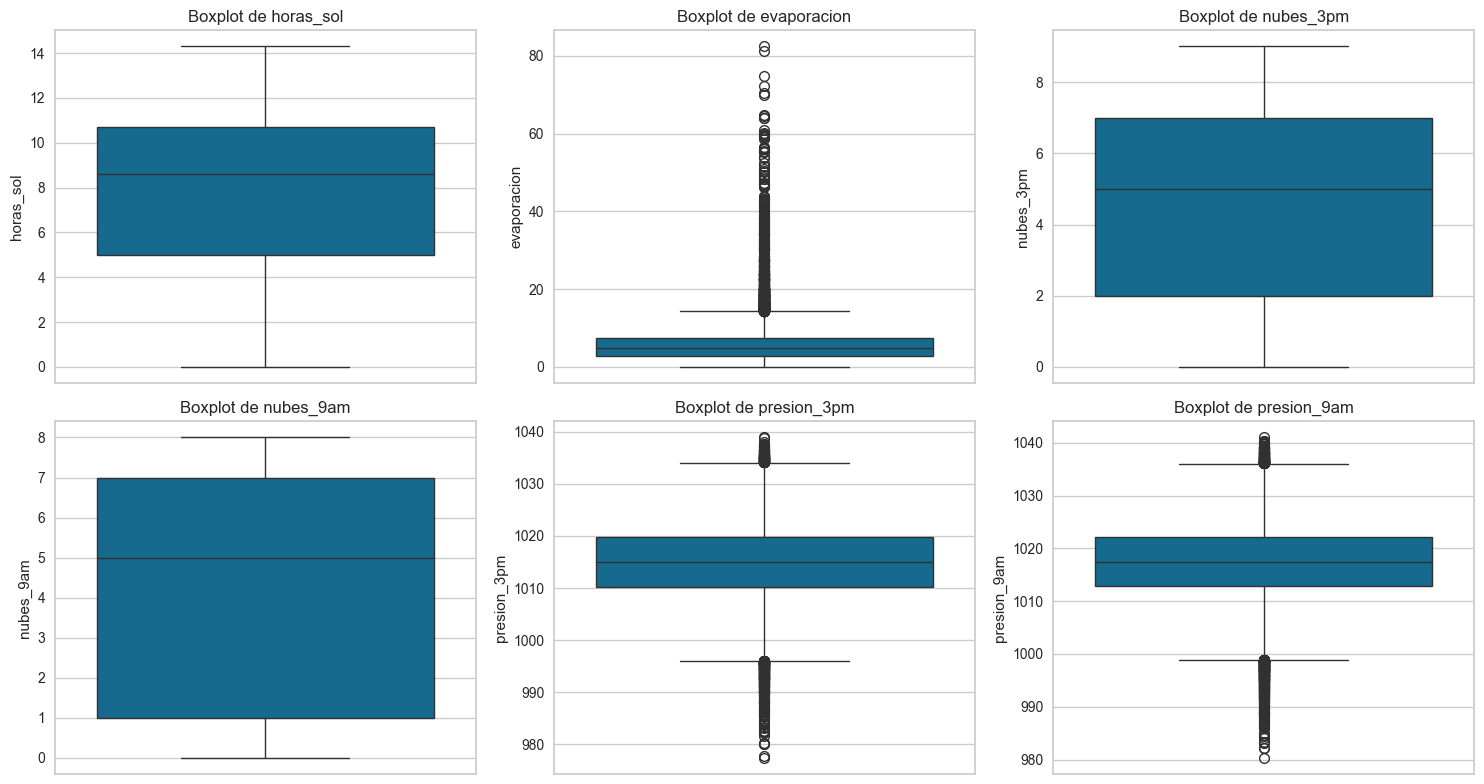

In [ ]:
# BOXPLOTS
cols_num = ['horas_sol', 'evaporacion', 'nubes_3pm', 'nubes_9am', 'presion_3pm','presion_9am']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

In [ ]:
def imputar_por_ubi_y_mes(datos, columna):
    """
    Imputa valores nulos de una columna usando la media agrupada por ubicacion y mes.
    """

    datos[columna] =datos[columna].fillna( datos.groupby(['ubicacion', 'mes'])[columna].transform('mean'))

    # Caso de no tener registros para esa configuracion
    datos[columna] = datos[columna].fillna(datos[columna].mean())

    return datos

In [ ]:
# Imputación X_train:
col_imputar = ['horas_sol','evaporacion','nubes_3pm','nubes_9am','presion_9am','presion_3pm']

for col in col_imputar:
    X_train = imputar_por_ubi_y_mes(X_train, col)

In [ ]:
# Imputación X_test con los valores de X_train
for col in col_imputar:

    # medias del train
    medias_grupo = X_train.groupby(['ubicacion', 'mes'])[col].mean()
    media_global = X_train[col].mean()

    # imputación por grupo
    X_test[col] = X_test.apply(
        lambda row: medias_grupo.get((row['ubicacion'], row['mes']), None)
        if pd.isnull(row[col]) else row[col],
        axis=1)

    # imputación global
    X_test[col] = X_test[col].fillna(media_global)


### Análisis de distribuciones:

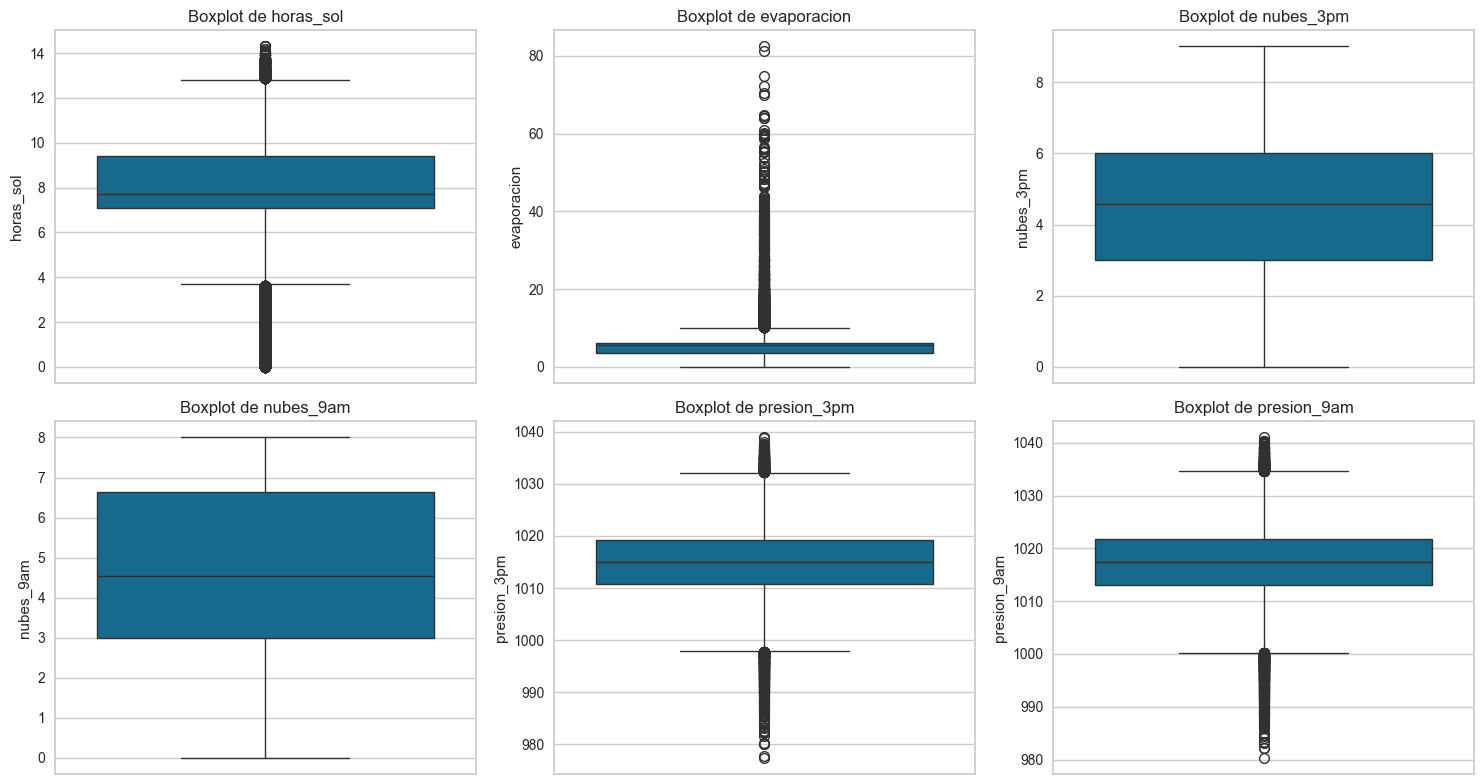

In [ ]:
cols_num = ['horas_sol', 'evaporacion', 'nubes_3pm', 'nubes_9am', 'presion_3pm','presion_9am']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Al comparar las distribuciones antes y después de imputar por la media, observamos que la forma general de las variables se conserva, ya que las medianas y los rangos intercuartílicos no presentan cambios significativos. La imputación genera una mayor concentración de observaciones alrededor del valor medio y una reducción de la variabilidad. Si bien la presencia de valores atípicos podría afectar a la media y hacer que otras medidas resulten más robustas, decidimos mantener este criterio ya que no se observaron alteraciones importantes en la distribución ni en el comportamiento general de las variables.

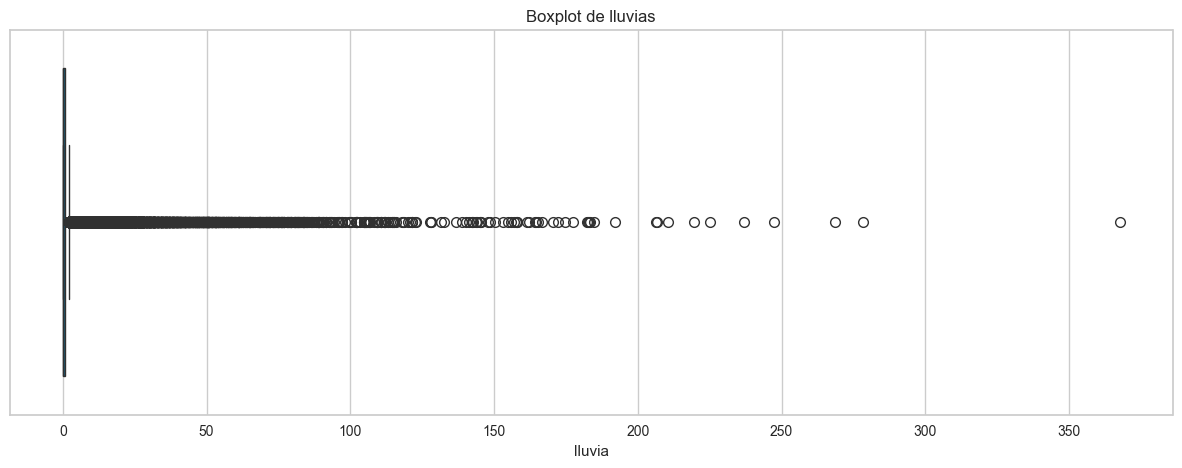

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(data=X_train, x='lluvia')
plt.title(f"Boxplot de lluvias")

plt.show()

Observamos una distribución asimetrica a la derecha. Como la mayoria de los días no llovió, se concentran los datos al principio del eje en el cero.

Los datos atipicos representan los días que si hubo precipitaciones. Como el cero es lo normal, cualquier dia con lluvias moderadas o tormentan se representan compo atipico.

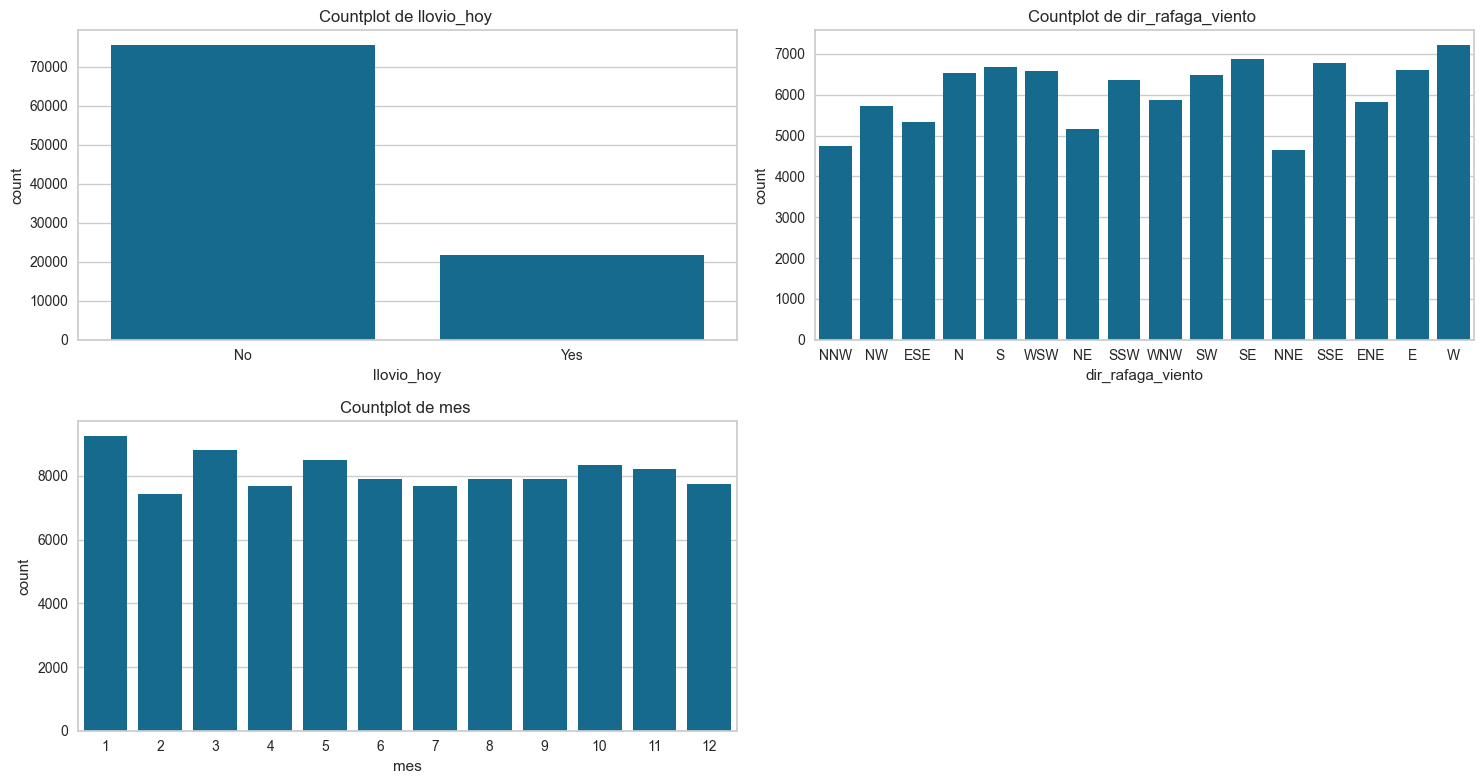

In [ ]:
cols_cat = ['llovio_hoy','dir_rafaga_viento','mes']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_cat):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=X_train, x=col)
    plt.title(f"Countplot de {col} ")

plt.tight_layout()
plt.show()

En base al countplot con las variables llovio_hoy, dir_rafaga_viento y mes, podemos observar:

Para la variable mes, las observaciones se distribuyen de manera uniforme a lo largo de los doce meses, dando a entender que existe la misma cantidad de datos para todas las estaciones climaticas sin sesgos temporales.

Para dir_rafaga_viento la distribución demuestra un comportamiento variado y bastante equilibrado entre los 16 puntos, lo que indica que no hay una unica direccion del viento que domine todo el dataset.

Por ultimo en llovio_hoy el grafico expone un fuerte desbalance de clases, evidenciando que en la gran mayoria de los dias registrados no hubo precipitaciones significativas.

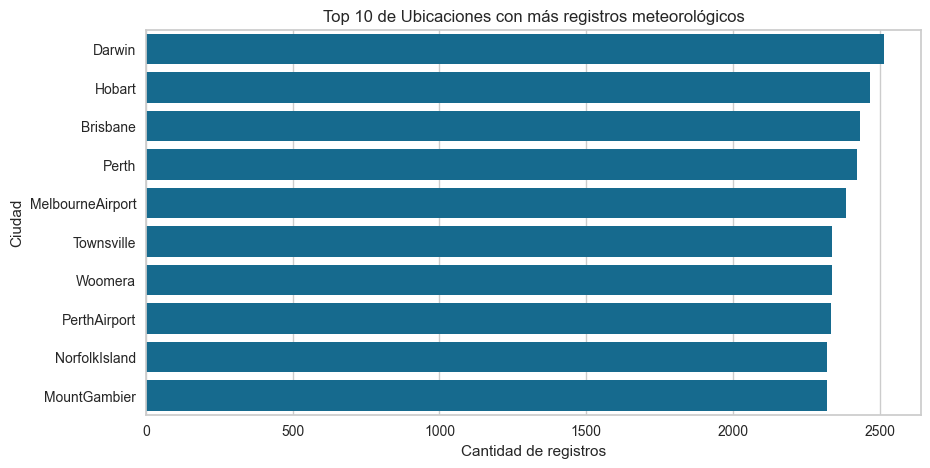

In [ ]:
#  Countplot con el Top 10 de ubicaciones
plt.figure(figsize=(10, 5))

top_10_ubicaciones = X_train['ubicacion'].value_counts().head(10).index
sns.countplot(data=X_train, y='ubicacion', order=top_10_ubicaciones)

plt.title("Top 10 de Ubicaciones con más registros meteorológicos")
plt.xlabel("Cantidad de registros")
plt.ylabel("Ciudad")
plt.show()

Hacemos un countplot aparte con la variable ubicacion pues es categorica.

Podemos observar que el top 10 de las ubicaciones con mas registros estan dentro del intervalo de 2000 y 2500.

Siendo el top 1 Darwing y el top 10 MountGambier.

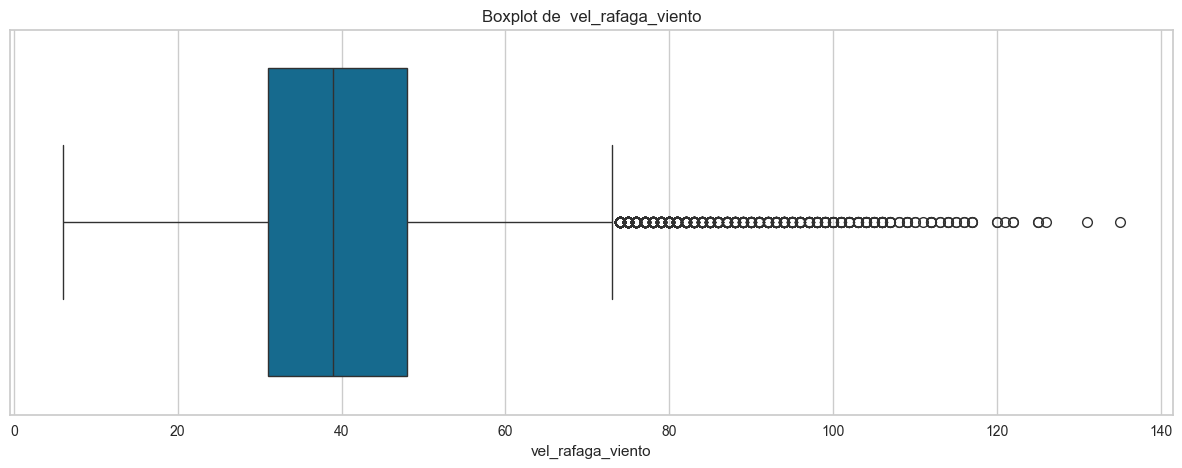

In [ ]:
plt.figure(figsize=(15,5))

sns.boxplot(data=X_train, x= 'vel_rafaga_viento')
plt.title(f"Boxplot de  vel_rafaga_viento")

plt.show()

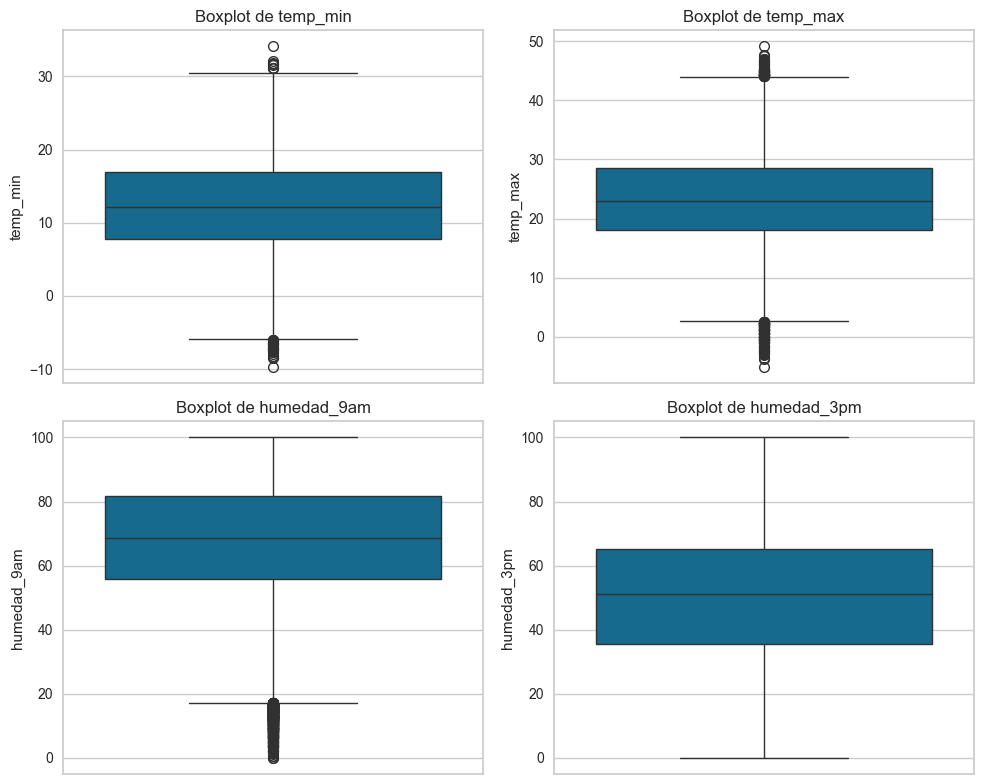

In [ ]:
cols_num = ['temp_min', 'temp_max','humedad_9am', 'humedad_3pm']

plt.figure(figsize=(10,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Viendo los boxplots de temp_min y temp_max, vemos que presentan distribuciones bastante simétricas, reflejando la variabilidad climatica sin una presencia significativa de valores atipicos severos.

 Por otro lado, al analizar las variables de humedad, se evidencia un claro contraste a lo largo del día: la humedad_9am es mas alta y concentrada en valores elevados, presentando algunos outliers en el extremo inferior, mientras que hacia la tarde, humedad_3pm, la distribución se desplaza hacia valores menores.

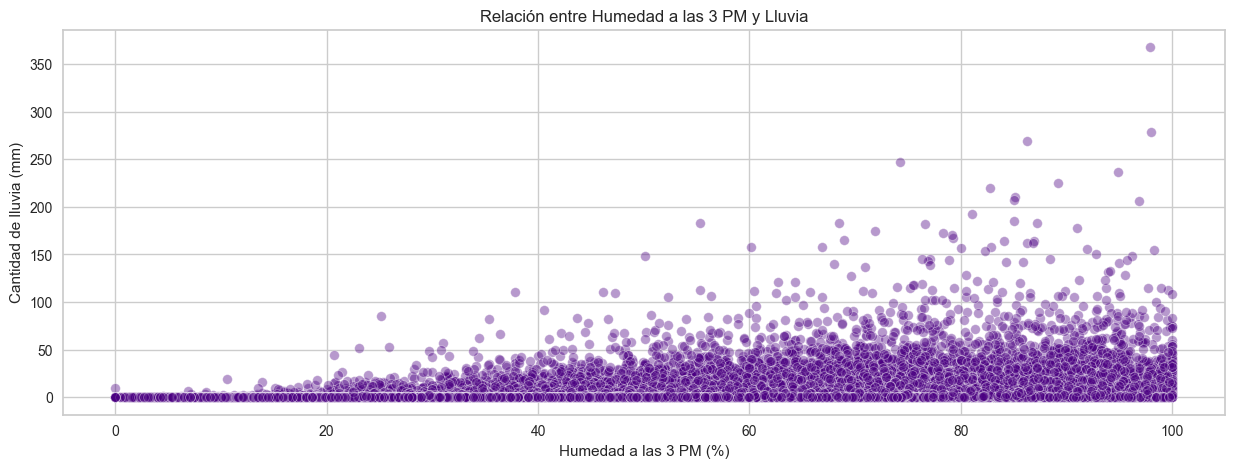

In [ ]:
# SCATTERPLOT (humedad_3pm vs lluvia)

plt.figure(figsize=(15,5))
sns.scatterplot( data=X_train, x='humedad_3pm', y='lluvia', alpha=0.4, color='indigo')
plt.title('Relación entre Humedad a las 3 PM y Lluvia')
plt.xlabel('Humedad a las 3 PM (%)')
plt.ylabel('Cantidad de lluvia (mm)')
plt.show()

Se muestra una relación positiva entre la humedad a las 3 PM y la cantidad de lluvia. A medida que aumenta la humedad, también tienden a incrementarse las precipitaciones registradas. Sin embargo, la dispersión de los puntos indica que la relación no es completamente lineal y que intervienen otros factores climáticos en la ocurrencia de lluvia.

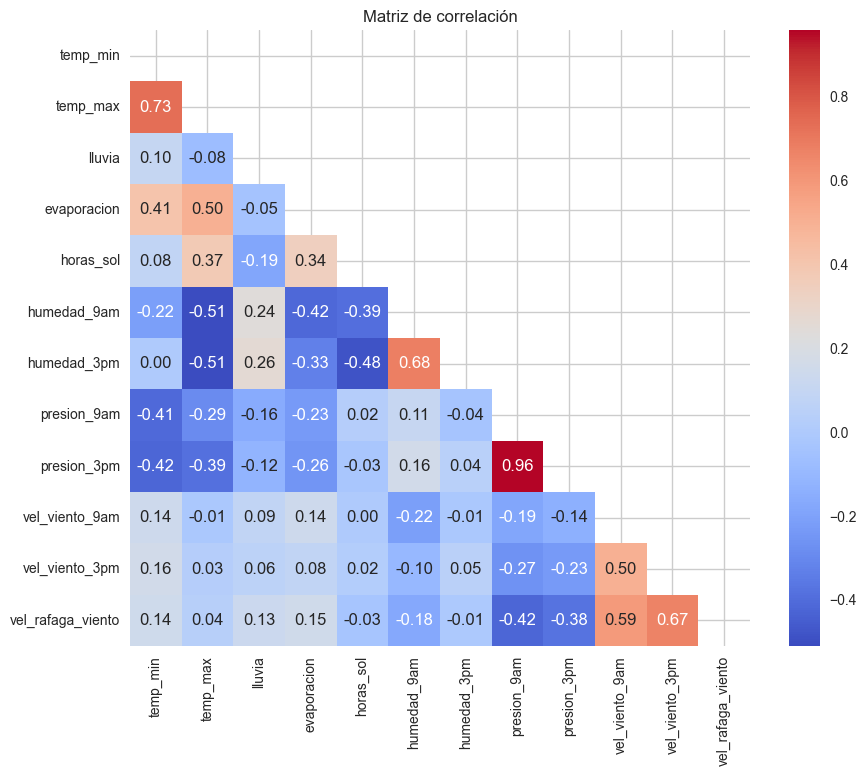

In [ ]:
vars_corr = ['temp_min','temp_max','lluvia','evaporacion','horas_sol','humedad_9am','humedad_3pm',
             'presion_9am','presion_3pm','vel_viento_9am','vel_viento_3pm','vel_rafaga_viento']
corr = X_train[vars_corr].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de correlación')
plt.show()

### Codificación de variables categóricas:

In [ ]:
# Lueve_hoy:
X_train['llovio_hoy'] = X_train['llovio_hoy'].map({'No':0, 'Yes':1})
X_test['llovio_hoy'] = X_test['llovio_hoy'].map({'No':0, 'Yes':1})

In [ ]:
# Lueve_manana:
y_train = y_train.map({'No':0, 'Yes':1})
y_test =  y_test.map({'No':0, 'Yes':1})

In [ ]:
# One-Hot Encoding:
cols_cat = ['ubicacion','dir_rafaga_viento','dir_viento_9am','dir_viento_3pm']

X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

#Alinear
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Las variables categóricas fueron transformadas a variables numéricas para utilizarlas en el modelo de regresión logística. La variable 'llovio_hoy' fue codificada como binaria, mientras que las variables 'ubicacion','dir_rafaga_viento','dir_viento_9am'y'dir_viento_3pm' fueron transformadas con One-Hot Encoding.

### Estandarización/Escalado:

In [ ]:
cols_num = ['temp_max', 'lluvia', 'evaporacion', 'horas_sol', 'humedad_3pm', 'presion_3pm', 'vel_viento_3pm', 'vel_rafaga_viento',
            'nubes_3pm','temp_3pm','humedad_9am','presion_9am','vel_viento_9am']

scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

# 4) Regresión logística.

In [ ]:
# Inicializar y entrenar un modelo de regresión logística
modelo_log = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
modelo_log.fit(X_train, y_train)

# Predicción
y_pred = modelo_log.predict(X_test)

# Probabilidad
y_prob = modelo_log.predict_proba(X_test)[:,1]

In [ ]:
# Reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.93      0.81      0.86     18976
           1       0.54      0.78      0.64      5376

    accuracy                           0.80     24352
   macro avg       0.73      0.80      0.75     24352
weighted avg       0.84      0.80      0.81     24352



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.8019464520367937
Precision: 0.5351111111111111
Recall: 0.7838541666666666
F1-score: 0.636027469624934


Accuracy (0.80): El modelo acertó el 80% de todas sus predicciones

Precision (0.53): El modelo tiene un 53% de acierto y un 47% de falsas alarmas.

Recall (0.78): De todos los dias en los q llovio, el modelo fue capaz de detectar el 78%.

F1-score (0.63): Es el balance general entre la precisión y el recall.

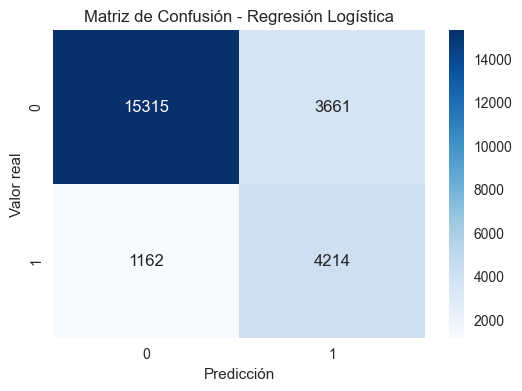

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

Falso negativo y falso positivo:

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 15315
False Positives: 3661
False Negatives: 1162
True Positives: 4214


Falso positivo (FP): El modelo predice lluvia para el día siguiente, pero en realidad no llueve.

Falso negativo (FN):El modelo predice que no lloverá, pero finalmente sí llueve.

El modelo logra identificar correctamente muchos dias sin lluvia(15315) y tambien una buena cantidad de dias lluviosos(4214).

Sin embargo, todavía comete algunos errores: en ciertos casos predice lluvia cuando finalmente no llueve (falsos positivos), y en otros no logra anticipar lluvias reales (falsos negativos).

In [ ]:
# Probabilidades
y_prob = modelo_log.predict_proba(X_test)[:,1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Área bajo la curva
roc_auc = auc(fpr, tpr)

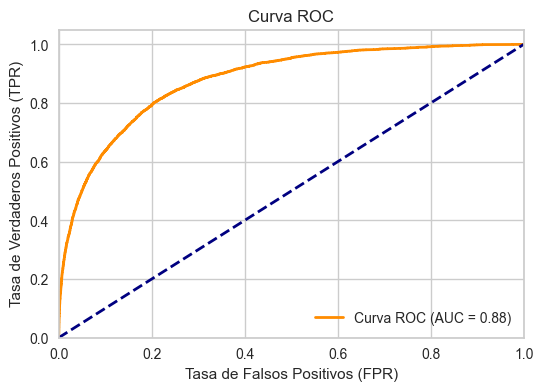

In [ ]:
# Grafico la curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

La regresión logística alcanza un AUC cercano a 0.88, mostrando una muy buena capacidad para diferenciar días lluviosos de días sin lluvia.

In [ ]:
roc_auc

0.8790038925265248

In [ ]:
fpr, tpr, thresholds

(array([0.       , 0.       , 0.       , ..., 0.9771817, 0.9771817,
        1.       ]),
 array([0.00000000e+00, 1.86011905e-04, 8.74255952e-03, ...,
        9.99813988e-01, 1.00000000e+00, 1.00000000e+00]),
 array([       inf, 0.99974877, 0.99707208, ..., 0.01618217, 0.01617716,
        0.00258938]))

### Mejor Umbral

El umbral (threshold) representa el valor de probabilidad a partir del cual el modelo clasifica un caso como positivo (lluvia). Por defecto suele utilizarse 0.5, es decir, si la probabilidad predicha es mayor o igual a 50%, el modelo predice lluvia.

Sin embargo, 0.5 no siempre es el mejor umbral. El valor óptimo depende del problema y del equilibrio deseado entre precisión y recall. En problemas meteorológicos suele ser importante reducir los falsos negativos, ya que no predecir una lluvia real puede generar mayores consecuencias.

In [ ]:
#UMBRAL
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    score = f1_score(y_test, y_pred_t)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Mejor umbral:", best_threshold)
print("Mejor F1-score:", best_f1)

Mejor umbral: 0.6500000000000001
Mejor F1-score: 0.6426104344664606


Se evaluaron distintos valores de threshold (umbral) para determinar cuál ofrecía el mejor equilibrio entre precisión y recall utilizando el F1-score como criterio de evaluación.

El mejor resultado se obtuvo con un umbral de 0.60, alcanzando un F1-score de aproximadamente 0.64. Esto indica que el modelo logra un mejor equilibrio entre la detección de días lluviosos y la reducción de falsas alarmas cuando se utiliza un umbral superior al valor por defecto de 0.5.

Concluimos que la selección del umbral tiene un impacto significativo en el desempeño del modelo y para este conjunto de datos, un umbral de 0.60 permite obtener el mejor compromiso entre precisión y recall según la métrica F1-score.

# 5)  Implementación del modelo base (Dummy Classifier).

In [ ]:
# Inicializar y entrenar un modelo
modelo_base = DummyClassifier(strategy="most_frequent")
modelo_base.fit(X_train, y_train)

# Predicción
y_pred_base = modelo_base.predict(X_test)

# Probabilidad:
y_probs_base = modelo_base.predict_proba(X_test)[:, 1]

In [ ]:
# Reporte de métricas
print("--- Reporte de Métricas ---")
print(classification_report(y_test, y_pred_base))

--- Reporte de Métricas ---
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     18976
           1       0.00      0.00      0.00      5376

    accuracy                           0.78     24352
   macro avg       0.39      0.50      0.44     24352
weighted avg       0.61      0.78      0.68     24352



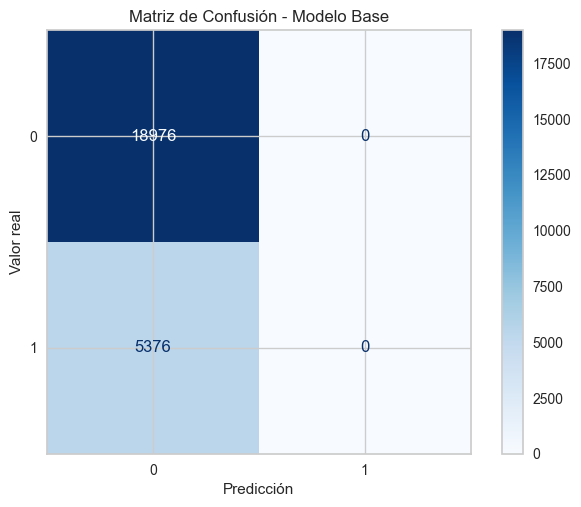

In [ ]:
ConfusionMatrixDisplay.from_estimator(modelo_base, X_test, y_test, cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title('Matriz de Confusión - Modelo Base')
plt.show()

Falso negativo y falso positivo:

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_base).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 18976
False Positives: 0
False Negatives: 5376
True Positives: 0


El modelo base logró identificar correctamente los días sin lluvia, pero no pudo detectar ningún día lluvioso. Esto pasa porque siempre predice la clase más frecuente (‘No lluvia’), por lo que no aprende realmente patrones del clima y funciona solo como referencia para comparar con modelos más avanzados.

In [ ]:
# Probabilidades
y_prob_base = modelo_base.predict_proba(X_test)[:,1]

# Curva ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

# Área bajo la curva
auc_base = auc(fpr_base, tpr_base)

print("AUC modelo base:", auc_base)

AUC modelo base: 0.5


Que el AUC del modelo base sea 0.5 refleja que el modelo no tiene ninguna capacidad para discriminar o separar las clases. Al predecir siempre de forma automatica la clase mas frecuente, su tasa de aciertos es equivalente a adivinar el clima mediante el azar.

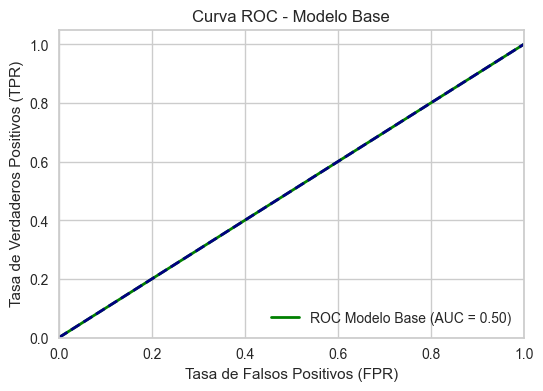

In [ ]:
# Curva ROC - Modelo Base
plt.figure(figsize=(6, 4))
plt.plot(fpr_base, tpr_base, color='green', lw=2, label='ROC Modelo Base (AUC = %0.2f)' % auc_base)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo Base')
plt.legend(loc="lower right")
plt.show()

La regresión logística supera ampliamente al modelo base, demostrando capacidad para aprender patrones climáticos relevantes y realizar predicciones significativamente mejores que un clasificador aleatorio o trivial.

Probamos distintos thresholds solamente en la regresión logística, porque el modelo base básicamente siempre predice la opción más común y no aporta probabilidades útiles para analizar distintos umbrales.

**¿El modelo logró un buen fitting?**

Consideramos que el modelo logró un buen fitting, ya que obtuvo métricas significativamente superiores al modelo base. La regresión logística alcanzó un AUC cercano a 0.88, mostrando una buena capacidad para distinguir entre días con lluvia y sin lluvia.

# Entrega 2:

# 6) Optimización de párametros.

In [ ]:
param_grid = {'penalty': ['l1', 'l2'],
              'C': [0.01, 0.1, 1, 10]}

cv_strat = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

grid = GridSearchCV(LogisticRegression(solver='liblinear',max_iter=1000,random_state=42),
    param_grid=param_grid,scoring='f1',cv=cv_strat,n_jobs=-1)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'penalty': 'l2'}
0.6181707077076851


Para optimizar los hiperparámetros ultilizamos Grid Search con validación cruzada estratificada de 5 folds.

La mejor combinación encontrada fue penalty = 'l2' y C = 10, obteniendo un F1-score promedio de 0,618. El modelo logra su mejor desempeño utilizando regularización L2 y una penalización baja, ya que el valor de C = 10 reduce el efecto de la regularización y permite que el modelo se ajuste mejor a los datos.

La optimización de hiperparámetros permitió identificar una configuración que mejora el equilibrio entre precisión y recall, alcanzando el mejor desempeño observado durante el proceso de validación cruzada.

In [ ]:
# Modelo optimizado
modelo_final = LogisticRegression(C=10,penalty='l2',solver='liblinear',max_iter=1000,random_state=42)

modelo_final.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=1000, random_state=42, solver='liblinear')

In [ ]:
# Predicción
y_pred = modelo_final.predict(X_test)

# Probabilidad:
y_prob = modelo_final.predict_proba(X_test)[:,1]

# 7) SHAP.

In [ ]:
scaler_shap = StandardScaler()

# Escalamos y convertimos  a DataFrames de Pandas
X_train_scaled = pd.DataFrame(scaler_shap.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler_shap.transform(X_test),columns=X_train.columns)

In [ ]:
# Inicializamos el LinearExplainer
explainer = shap.LinearExplainer(modelo_final, X_train_scaled)

# Valores SHAP
shap_values = explainer.shap_values(X_test_scaled)

In [ ]:
index = 0

## Gráficas :

Globales:

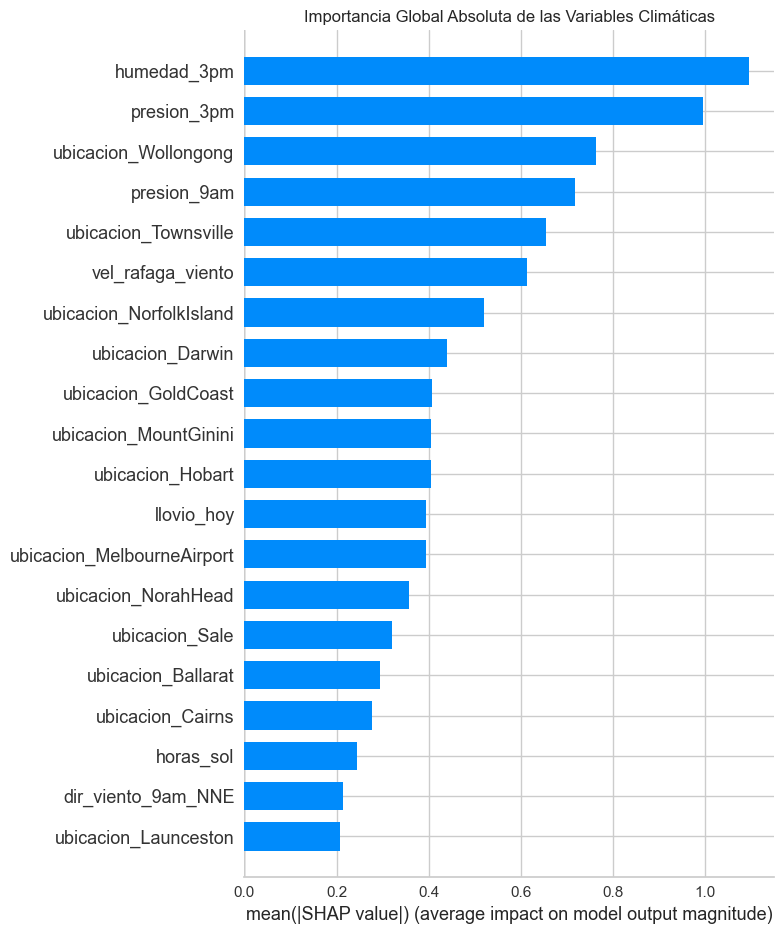

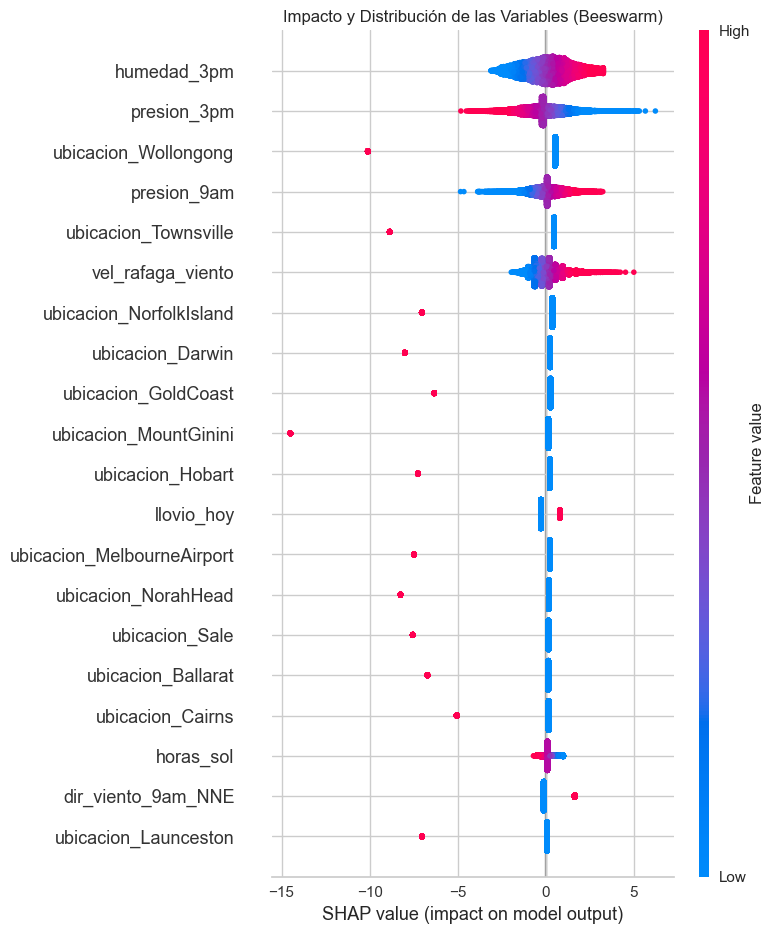

In [ ]:
# Gráfica 1: Importancia de características en barras
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("Importancia Global Absoluta de las Variables Climáticas")
plt.tight_layout()
plt.show()

# Gráfica 2: Gráfico de enjambre (Beeswarm) para ver la direccionalidad
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("Impacto y Distribución de las Variables (Beeswarm)")
plt.tight_layout()
plt.show()

**Análisis global**

Con el gráfico de importancia, se observa que las variables con mayor influencia sobre las predicciones son 'humedad_3pm' y 'presion_3pm', seguidas por 'ubicacion_Wollongong', 'presion_9am', 'ubicacion_Townsville' y 'vel_rafaga_viento'. Estas variables  son las que más contribuyen a las decisiones del modelo.

Y variables como 'ubicacion_Launceston', 'dir_viento_9am_NNE', 'horas_sol' y algunas ubicaciones muestran una influencia considerablemente menor sobre las predicciones, por lo que su aporte al modelo resulta más limitado.

El gráfico Beeswarm muestra no solo la importancia de cada variable, sino también la dirección de su efecto. Se observa que los valores elevados de 'humedad_3pm' tienden a incrementar la probabilidad de lluvia, mientras que determinados valores de presión atmosférica contribuyen a aumentar o disminuir dicha probabilidad según el caso. Esto confirma que las variables relacionadas con la humedad y la presión son factores determinantes para la predicción de lluvia.

Locales:

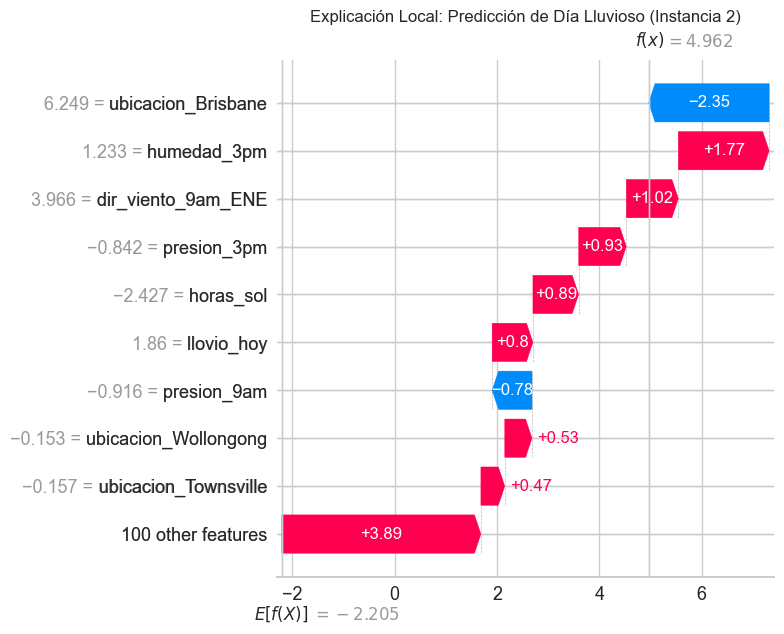

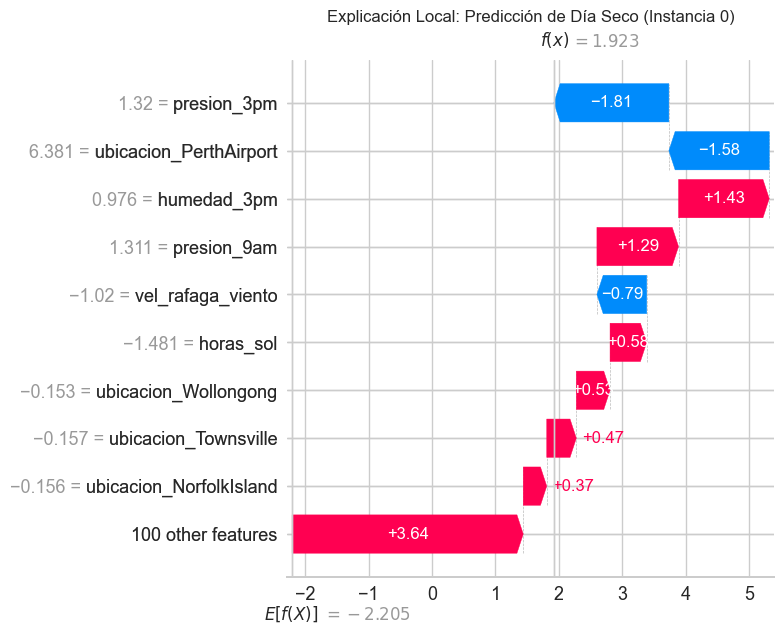

In [ ]:
# Buscamos índices reales para mostrar casos particulares de lluvia o no lluvia usando y_test
ind_lluvia = np.where(y_test.values == 1)[0][0]
ind_no_lluvia = np.where(y_test.values == 0)[0][0]

explanation = shap.Explanation(values=shap_values[ind_lluvia],base_values=explainer.expected_value,data=X_test_scaled.iloc[ind_lluvia],
    feature_names=X_test_scaled.columns)

explanation2 = shap.Explanation(values=shap_values[ind_no_lluvia],base_values=explainer.expected_value,data=X_test_scaled.iloc[ind_no_lluvia],
    feature_names=X_test_scaled.columns)

# Gráfica 1: Caso de Día Lluvioso
plt.figure(figsize=(8, 4))
shap.plots.waterfall(explanation, show=False)
plt.title(f"Explicación Local: Predicción de Día Lluvioso (Instancia {ind_lluvia})")
plt.tight_layout()
plt.show()

# Gráfica 2: Caso de Día Seco
plt.figure(figsize=(8, 4))
shap.plots.waterfall(explanation2, show=False)
plt.title(f"Explicación Local: Predicción de Día Seco (Instancia {ind_no_lluvia})")
plt.tight_layout()
plt.show()

**Análisis local**

Analizamos dos observaciones mediante gráficos Waterfall: un día clasificado como lluvioso y otro como día seco.

En la predicción correspondiente del día lluvioso, las variables que más influyeron en la clasificación fueron humedad_3pm, dirección del viento a las 9 AM (ENE), presión a las 3 PM y horas de sol, cuyos valores contribuyeron significativamente a aumentar la probabilidad de lluvia.

Y en la predicción del día seco, variables como presion_3pm, determinadas ubicaciones geográficas y la humedad_3pm tuvieron mas importancia en la decisión del modelo, algunas actuaron reduciendo la probabilidad de lluvia y otras aumentándola.

Los resultados obtenidos con SHAP muestran que las variables meteorológicas comos la humedad, la presión atmosférica, la velocidad y dirección del viento, son las más relevantes para la predicción de lluvia. Además, ciertas ubicaciones geográficas presentan una influencia considerable, lo que sugiere que las características climáticas propias de cada región también afectan las predicciones del modelo.


# 8) Modelo de AutoML con Pycaret.

In [ ]:
# Creamos el DataFrame unificado
df_train_auto = pd.DataFrame(X_train, columns=X_train.columns)
df_train_auto['RainTomorrow'] = y_train.values

# Inicializamos el entorno de PyCaret
clasif = setup(data=df_train_auto,target='RainTomorrow',session_id=42)

# Comparamos los modelos y los ordenamos por el F1-Score
mejor_modelo = compare_models(fold=5, sort='F1')
print(mejor_modelo)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(97405, 110)"
4,Transformed data shape,"(97405, 110)"
5,Transformed train set shape,"(68183, 110)"
6,Transformed test set shape,"(29222, 110)"
7,Numeric features,18
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8622,0.8919,0.5532,0.7573,0.6393,0.5567,0.5672,2.1380
lda,Linear Discriminant Analysis,0.8537,0.8765,0.5422,0.7256,0.6206,0.5323,0.5410,0.9860
lr,Logistic Regression,0.8549,0.8787,0.5321,0.7378,0.6182,0.5316,0.5424,7.9780
svm,SVM - Linear Kernel,0.8409,0.8729,0.5862,0.6830,0.6149,0.5175,0.5301,2.0100
gbc,Gradient Boosting Classifier,0.8555,0.8798,0.5178,0.7503,0.6127,0.5276,0.5413,8.4540
rf,Random Forest Classifier,0.8577,0.8855,0.5002,0.7754,0.6081,0.5261,0.5449,4.6160
ada,Ada Boost Classifier,0.8493,0.8686,0.5162,0.7222,0.6020,0.5123,0.5233,1.8400
et,Extra Trees Classifier,0.8571,0.8861,0.4821,0.7883,0.5983,0.5174,0.5406,6.4860
ridge,Ridge Classifier,0.8524,0.8765,0.4810,0.7629,0.5900,0.5056,0.5256,0.2300
knn,K Neighbors Classifier,0.8328,0.8115,0.4514,0.6839,0.5438,0.4467,0.4611,6.4800


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


El modelo seleccionado automáticamente por PyCaret fue Light Gradient Boosting Machine (LightGBM), obteniendo un Accuracy de 0,8622, un AUC de 0,8919 y un F1-score de 0,6393. Estos resultados fueron superiores a los obtenidos por la Regresión Logística optimizada mediante Grid Search, la cual alcanzó un Accuracy de 0,8549, un AUC de 0,8787 y un F1-score de 0,6182.

Aunque LightGBM presenta un mejor rendimiento, la Regresión Logística continúa siendo más fácil de interpretar y analizar, especialmente cuando se complementa con herramientas de explicabilidad como SHAP.

# Entrega 3:

# 9) Red Neuronal.

### Clase NeuralNetwork:

Para el desarrollo de este punto utilizamos la estructura de 'NeuralNetworkRegressor' vista en clase, le realizamos modificaciones para adecuar la red a nuestro problema de clasificación binaria.

In [ ]:
class NeuralNetwork:
    def __init__(self, epochs=100, batch_size=32, learning_rate=0.01):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.model = None

    def build_model(self, input_shape):
        # Adaptamos usando ReLU en las ocultas y dejamos 1 sola neurona con 'sigmoid' para clasificación binaria (Lluvia Sí/No)
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(30, activation='relu', input_shape=(input_shape,)),
            tf.keras.layers.Dense(26, activation='relu'),
            tf.keras.layers.Dense(24, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid') ])

        # Compilamos con binary_crossentropy para clasificación binaria
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=self.epochs,
            batch_size=self.batch_size)
        return history.history['loss'], history.history['val_loss']

    def evaluate(self, X_test, y_test):
        loss, accuracy = self.model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Loss: {loss:.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")

    def predict(self, X_new):
        # Devuelve las probabilidades (valores entre 0 y 1)
        return self.model.predict(X_new)

### Red Neuronal:

In [ ]:
X_train_nn, X_valid, y_train_nn, y_valid = train_test_split(X_train_scaled,y_train,test_size=0.2,random_state=42,stratify=y_train)

In [ ]:
# Inicializamos la Red Neuronal
nn = NeuralNetwork(epochs=50,batch_size=64,learning_rate=0.001)

# Construcción del modelo
nn.build_model(input_shape=X_train_nn.shape[1])

# Entrenamiento
history = nn.train(X_train_nn,y_train_nn,X_valid,y_valid)

Epoch 1/50
1218/1218 [==============================] - 4s 2ms/step - loss: 0.3662 - accuracy: 0.8397 - val_loss: 0.3314 - val_accuracy: 0.8566
Epoch 2/50
1218/1218 [==============================] - 3s 2ms/step - loss: 0.3247 - accuracy: 0.8612 - val_loss: 0.3202 - val_accuracy: 0.8637
Epoch 3/50
1218/1218 [==============================] - 2s 2ms/step - loss: 0.3151 - accuracy: 0.8641 - val_loss: 0.3171 - val_accuracy: 0.8648
Epoch 4/50
1218/1218 [==============================] - 2s 1ms/step - loss: 0.3088 - accuracy: 0.8674 - val_loss: 0.3175 - val_accuracy: 0.8637
Epoch 5/50
1218/1218 [==============================] - 2s 1ms/step - loss: 0.3052 - accuracy: 0.8696 - val_loss: 0.3165 - val_accuracy: 0.8647
Epoch 6/50
1218/1218 [==============================] - 2s 1ms/step - loss: 0.3017 - accuracy: 0.8716 - val_loss: 0.3165 - val_accuracy: 0.8651
Epoch 7/50
1218/1218 [==============================] - 3s 2ms/step - loss: 0.2986 - accuracy: 0.8723 - val_loss: 0.3201 - val_accuracy:

La red neuronal mostró capacidad de aprendizaje, evidenciada por la disminución sostenida de la pérdida de entrenamiento. Sin embargo, a partir de aproximadamente las primeras 10–15 épocas, la pérdida de validación dejó de disminuir y comenzó a incrementarse ligeramente, indicando la aparición de sobreajuste

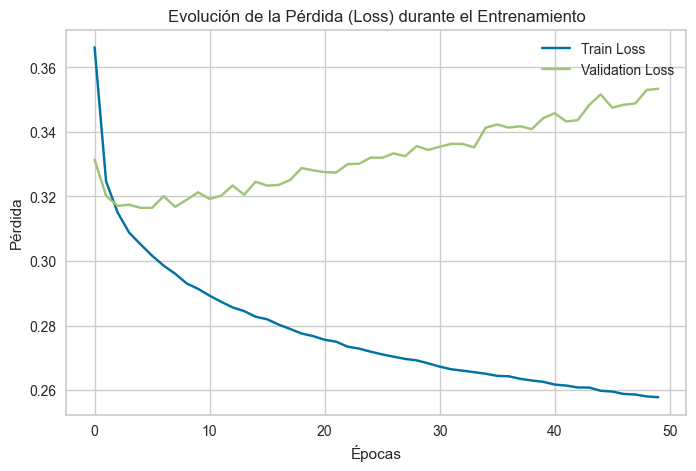

761/761 [==============================] - 1s 1ms/step
---Métricas---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     18976
           1       0.68      0.63      0.66      5376

    accuracy                           0.85     24352
   macro avg       0.79      0.77      0.78     24352
weighted avg       0.85      0.85      0.85     24352

Matriz de Confusión:
[[17383  1593]
 [ 1976  3400]]


In [ ]:
# Gráfico de Evolución de la Pérdida
plt.figure(figsize=(8, 5))
plt.plot(history[0], label='Train Loss')
plt.plot(history[1], label='Validation Loss')
plt.title('Evolución de la Pérdida (Loss) durante el Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Épocas')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Predicciones
y_pred_prob = nn.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("---Métricas---")
print(classification_report(y_test, y_pred))

print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

**¿Consigue un mejor fitting que con la regresión logística?**

El modelo base de la red neuronal no consigue un mejor fitting que la regresión logística debido a un problema de overfitting. Mientras la pérdida en el conjunto de entrenamiento disminuye continuamente, la curva de validación comienza a subir de forma sostenida a partir de la época 10, lo que demuestra que el modelo memorizó el ruido de los datos de entrenamiento y perdió capacidad de generalización. Para que la red neuronal supere este rendimiento, es necesario aplicar técnicas de regularización o ajustar sus hiperparámetros de manera automatizada.

### Optimización de parámetros:

In [ ]:
def objective(trial):
    # Sugerimos los hiperparámetros a probar en este intento
    # Cantidad de neuronas por capa
    neu_1 = trial.suggest_int('neu_1', 16, 64, step=16)
    neu_2 = trial.suggest_int('neu_2', 16, 64, step=16)

    # Tasa de aprendizaje
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # Armamos la arquitectura de la red con las sugerencias
    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(neu_1 , activation='relu', input_shape=(X_train_nn.shape[1],)),
        tf.keras.layers.Dense(neu_2, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')])

    # Compilamos
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Entrenamos
    model.fit(X_train_nn, y_train_nn, validation_data=(X_valid, y_valid), epochs=15, batch_size=64, verbose=0)

    # Evaluamos el modelo en validación usando F1-Score
    y_pred_prob = model.predict(X_valid, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    score = f1_score(y_valid, y_pred)

    return score

# Creamos el estudio indicando que queremos maximizar la métrica
study = optuna.create_study(direction='maximize')

# Ejecutamos 10 pruebas para encontrar la mejor combinación
study.optimize(objective, n_trials=10)

print("Mejor F1-Score en Validación:", study.best_value)
print("Mejores Hiperparámetros encontrados:", study.best_params)

[I 2026-06-19 16:00:27,422] A new study created in memory with name: no-name-1a9dd87d-8b9e-4109-9f71-02d0ca8ebd66
[I 2026-06-19 16:00:53,316] Trial 0 finished with value: 0.654354944335298 and parameters: {'neu_1': 16, 'neu_2': 32, 'learning_rate': 0.0003500151427400006}. Best is trial 0 with value: 0.654354944335298.
[I 2026-06-19 16:01:21,637] Trial 1 finished with value: 0.6522370331265672 and parameters: {'neu_1': 64, 'neu_2': 16, 'learning_rate': 0.0011385710099600904}. Best is trial 0 with value: 0.654354944335298.
[I 2026-06-19 16:01:49,754] Trial 2 finished with value: 0.6566225599371152 and parameters: {'neu_1': 32, 'neu_2': 32, 'learning_rate': 0.00016623425427665122}. Best is trial 2 with value: 0.6566225599371152.
[I 2026-06-19 16:02:17,846] Trial 3 finished with value: 0.6553323029366306 and parameters: {'neu_1': 64, 'neu_2': 32, 'learning_rate': 0.0001936897040033329}. Best is trial 2 with value: 0.6566225599371152.
[I 2026-06-19 16:02:46,567] Trial 4 finished with value:

Mejor F1-Score en Validación: 0.6574457083764219
Mejores Hiperparámetros encontrados: {'neu_1': 32, 'neu_2': 16, 'learning_rate': 0.0003679231474164993}


La optimización automatizada mediante Optuna se ejecutó a lo largo de 10 intentos con el objetivo de maximizar el F1-Score en el conjunto de validación, logrando estabilizar el aprendizaje de la red neuronal. El mejor resultado se obtuvo en el intento 7, alcanzando un F1-Score de 0.6574 mediante una configuración de 32 neuronas en la primera capa ocultay 16 en la segunda, con una tasa de aprendizaje de aproximadamente  0.000367.

2/2 [==============================] - 0s 4ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

3416/3416 [==============================] - 3s 741us/step


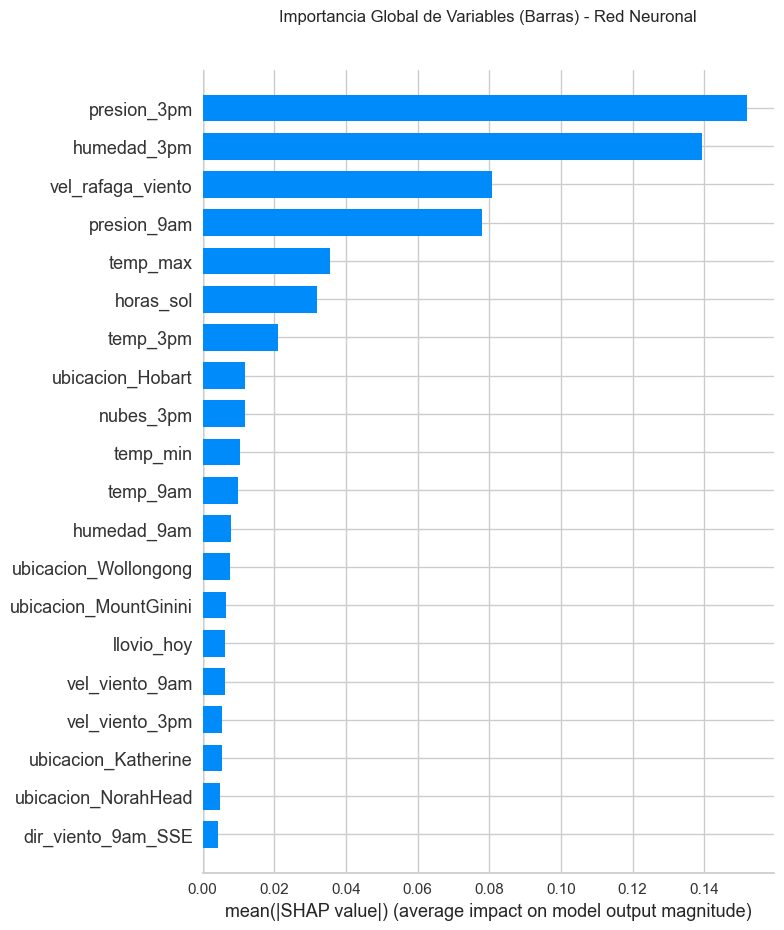

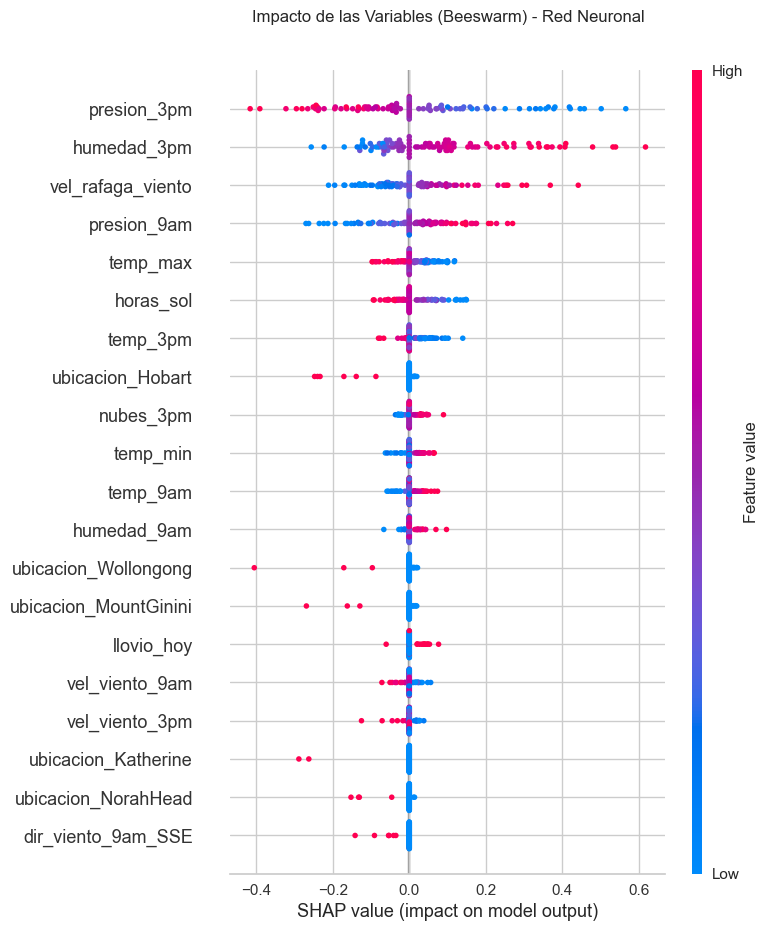

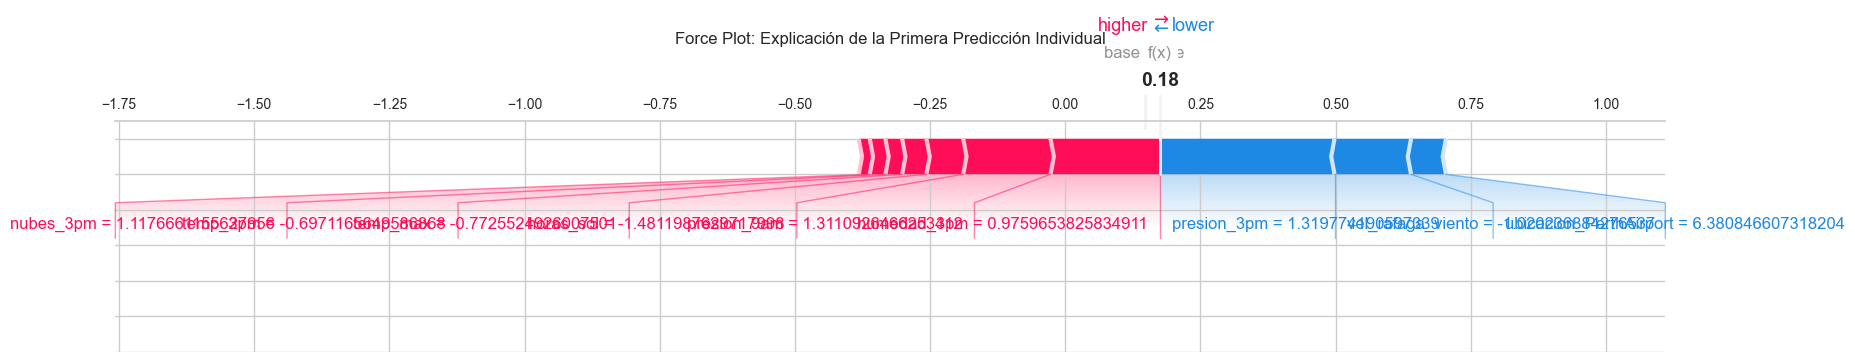

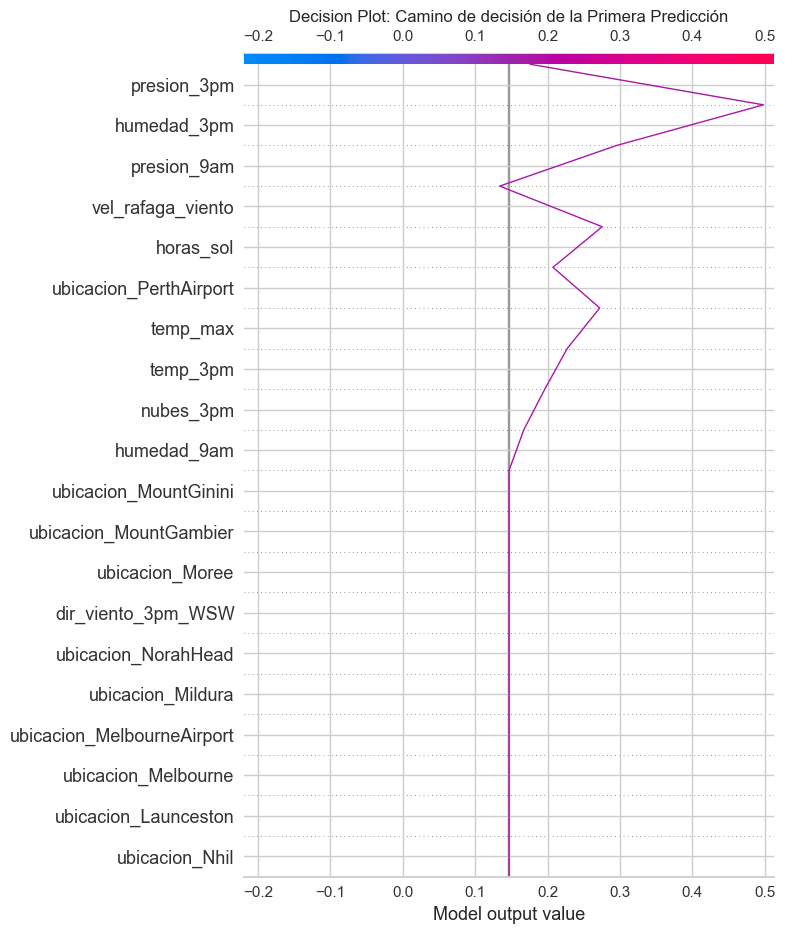

In [ ]:
# Entrenamos el mejor modelo
best_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train_nn.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')])

optimizer = tf.keras.optimizers.Adam(learning_rate= 0.0003679231474164993)
best_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamos
best_model.fit(X_train_nn, y_train_nn, validation_data=(X_valid, y_valid), epochs=30, batch_size=64, verbose=0)

# Configuración de SHAP
# Tomamos 50 muestras representativas como background
X_train_summary = shap.kmeans(X_train_nn, 50)
explainer = shap.KernelExplainer(best_model.predict, X_train_summary)

# Calculamos los valores SHAP sobre las primeras 100 filas de test
X_test_sample = X_test_scaled.iloc[:100]
shap_values = explainer.shap_values(X_test_sample)

# AJUSTE DE SHAPE PARA LAS GRÁFICAS
if isinstance(shap_values, list):
    correct_shap_values = shap_values[0]
else:
    correct_shap_values = shap_values

if len(correct_shap_values.shape) == 3:
    correct_shap_values = correct_shap_values.reshape(correct_shap_values.shape[0], correct_shap_values.shape[1])


# GRÁFICOS GLOBALES
#  Gráfico de Barras (Importancia promedio)
shap.summary_plot(correct_shap_values, X_test_sample, feature_names=X_train_scaled.columns, plot_type="bar", show=False)
plt.title("Importancia Global de Variables (Barras) - Red Neuronal", y=1.05)
plt.tight_layout()
plt.show()

# Summary Plot de Dispersión (Beeswarm)
shap.summary_plot(correct_shap_values, X_test_sample, feature_names=X_train_scaled.columns, show=False)
plt.title("Impacto de las Variables (Beeswarm) - Red Neuronal", y=1.05)
plt.tight_layout()
plt.show()

#  GRÁFICOS LOCALES
shap.initjs()
#  Force Plot Local
base_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
shap.force_plot(base_value, correct_shap_values[0, :], X_test_sample.iloc[0], feature_names=X_train_scaled.columns, matplotlib=True, show=False)
plt.title("Force Plot: Explicación de la Primera Predicción Individual", y=1.3)
plt.show()

#  Decision Plot Local
shap.decision_plot(base_value, correct_shap_values[0, :], feature_names=list(X_train_scaled.columns), show=False)
plt.title("Decision Plot: Camino de decisión de la Primera Predicción")
plt.tight_layout()
plt.show()

Al comparar los resultados de explicabilidad global, se nota una diferencia importante entre ambos modelos. La regresión logística considera que la humedad de la tarde (humedad_3pm) es la variable más influyente para predecir, mientras que la red neuronal le da mayor importancia a la presión (presion_3pm).
En los gráficos Beeswarm también observamos que la regresión logística presenta un comportamiento más lineal y predecible: a medida que aumenta la humedad, aumenta de forma directa su influencia en la predicción. En cambio, la red neuronal muestra patrones más dispersos y complejos, lo que indica que variables como la presión atmosférica o la ubicación interactúan entre sí y modifican su impacto según las condiciones del resto de las variables climáticas.
A nivel local, los gráficos Waterfall de la regresión logística y los Force Plot de la red neuronal muestran que ambos modelos pueden llegar a decisiones diferentes para un mismo tipo de caso. Esto refleja que la red neuronal tiene una mayor capacidad para captar relaciones complejas entre las variables y adaptarse a distintas situaciones, mientras que la regresión logística se basa en una combinación más simple y lineal de los factores analizados.

# 10) Comparación de modelos.

Para realizar una evaluación de todos los algoritmos desarrollados en el trabajo práctico, calculamos las métricas obtenidas por cada uno en el conjunto de test.

In [ ]:
# Regresión Logística
y_pred_lr = modelo_final.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_lr)
f1_log = f1_score(y_test, y_pred_lr)

# PyCaret
df_test_auto = pd.DataFrame(X_test, columns=X_train.columns)
df_test_auto['RainTomorrow'] = y_test.values
predicciones_pycaret = predict_model(mejor_modelo, data=df_test_auto)
y_pred_pycaret = predicciones_pycaret['prediction_label'].astype(int)
acc_pycaret = accuracy_score(y_test, y_pred_pycaret)
f1_pycaret = f1_score(y_test, y_pred_pycaret)

# Red Neuronal
acc_nn = accuracy_score(y_test, y_pred)
f1_nn = f1_score(y_test, y_pred)

# TABLA
data_comparacion = {
    'Modelo': ['Regresión Logística (Optimizado)', 'AutoML PyCaret (LightGBM - Ganador)', 'Red Neuronal (Optimizada con Optuna)'],
    'Accuracy General': [acc_log, acc_pycaret, acc_nn],
    'F1-Score (Clase 1 - Lluvia)': [f1_log, f1_pycaret, f1_nn],
    'Frontera de Decisión': ['Lineal Estricta', 'No Lineal (Árboles)', 'No Lineal Profunda']}

df_comparacion = pd.DataFrame(data_comparacion)
df_comparacion['Accuracy General'] = df_comparacion['Accuracy General'].map('{:.4f}'.format)
df_comparacion['F1-Score (Clase 1 - Lluvia)'] = df_comparacion['F1-Score (Clase 1 - Lluvia)'].map('{:.4f}'.format)

print("TABLA COMPARATIVA ")
display(df_comparacion)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8585,0.8927,0.5402,0.7488,0.6276,0.5431,0.5541


TABLA COMPARATIVA 


,Modelo,Accuracy General,F1-Score (Clase 1 - Lluvia),Frontera de Decisión
0,Regresión Logística (Optimizado),0.8522,0.6101,Lineal Estricta
1,AutoML PyCaret (LightGBM - Ganador),0.8585,0.6276,No Lineal (Árboles)
2,Red Neuronal (Optimizada con Optuna),0.8534,0.6558,No Lineal Profunda


Para comparar los modelos elegimos como métrica el F1-Score de la clase 1 (días con lluvia). Debido al desbalance en el conjunto de datos, donde los días sin lluvia son considerablemente más frecuentes. El F1-Score combina Precisión y Recall, permitiendo evaluar de manera equilibrada la capacidad del modelo para detectar correctamente los días lluviosos.

La Red Neuronal Optimizada con Optuna presentó el mejor desempeño, alcanzando un F1-Score de0.6558. Aunque su Accuracy general (0.8534) fue ligeramente inferior al de los demás modelos, logró el mejor equilibrio entre la detección de casos positivos y la reducción de falsos positivos.

LightGBM seleccionado mediante AutoML de PyCaret, con un F1-Score de 0.6276 y el mayor Accuracy general (0.8585). La diferencia respecto a la red neuronal es mínima, por lo que ambos modelos pueden considerarse altamente competitivos.

Por último, la Regresión Logística obtuvo un F1-Score de 0.6101 y un Accuracy de 0.8522. Si bien obtuvo un rendimineto menor presenta la ventaja de ser más simple e interpretable, permitiendo comprender con mayor facilidad el impacto de cada variable en la predicción.

Considerando el F1-Score de la clase lluvia como criterio principal, la Red Neuronal Optimizada con Optuna resultó ser el mejor modelo para este problema. No obstante, la diferencia con LightGBM es muy pequeña, lo que indica que ambos enfoques son capaces de capturar eficazmente los patrones presentes en los datos meteorológicos.

# 11) Docker:

In [ ]:
# Guardar todo el pipeline y modelo en un único archivo binario
save_model(mejor_modelo, 'best_rain_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['temp_min', 'temp_max', 'lluvia',
                                              'evaporacion', 'horas_sol',
                                              'vel_rafaga_viento',
                                              'vel_viento_9am', 'vel_viento_3pm',
                                              'humedad_9am', 'humedad_3pm',
                                              'presion_9am', 'presion_3pm',
                                              'nubes_9am', 'nubes_3pm',
                                              'temp_9am', 'temp_3pm',
                                              'llovio_hoy', 'mes'],
                                     transforme...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, importance_type='split',


# 12) Conclusión:

A lo largo de este trabajo se aplicaron distintas técnicas aprendizaje automático para abordar el problema de predicción de lluvia en Australia. El proceso incluyó etapas de exploración y preparación de datos, análisis de variables, entrenamiento y optimización de modelos, evaluación de desempeño y análisis de explicabilidad.

Los resultados obtenidos demostraron que los modelos más complejos, como LightGBM y la Red Neuronal Optimizada con Optuna, lograron un mejor desempeño que la Regresión Logística tradicional, evidenciando la existencia de relaciones no lineales entre las variables meteorológicas y la ocurrencia de lluvia. Sin embargo, también se observó que la diferencia de rendimiento entre los mejores modelos fue reducida, lo que indica que las variables disponibles contienen patrones predictivos sólidos que pueden ser aprovechados por distintos enfoques de modelado.

Por otra parte, el análisis de explicabilidad permitió comprender qué factores influyen con mayor fuerza en las predicciones realizadas. Variables relacionadas con la humedad, la presión atmosférica y las condiciones climáticas de la tarde aparecieron de manera consistente entre las más relevantes, coincidiendo con el conocimiento meteorológico esperado para este tipo de problema.

En conclusión, se logró construir modelos capaces de predecir la ocurrencia de lluvia con un desempeño satisfactorio, destacándose la Red Neuronal Optimizada con Optuna como el mejor modelo según la métrica seleccionada. Además de obtener buenos resultados predictivos, el trabajo permitió analizar e interpretar el comportamiento de los modelos, demostrando la importancia de combinar rendimiento y explicabilidad en proyectos de ciencia de datos.
